Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

In [31]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz

from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_validate
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


## 1. Load the data

In [32]:
#1. Load the data and inspect it
movie_metadata = pd.read_csv("movie_metadata.csv")
# Hint: Use pd.read_csv() to load your dataset, then explore with .info() and .head()
print(movie_metadata.info())
print(movie_metadata.head())
# Example:
# df = pd.read_csv("path/to/data.csv")
# print(df.info())
# print(df.head())

#movie_metadata = pd.read_csv("data/movie_metadata.csv")


<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   str    
 1   director_name              4939 non-null   str    
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   str    
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   str    
 10  actor_1_name               5036 non-null   str    
 11  movie_title                5043 non-null   str    
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64  
 14  act

## 2. Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

In [33]:
#2. Check and fix variable types, collapse factor levels
# Hint: Use .dtypes and .value_counts() to inspect variables.
# Use .replace() to collapse categories in your target variable.
# Use OrdinalEncoder to encode the target into integers for sklearn.


# Example (from Decision Trees.ipynb):
# print(df['target_col'].value_counts())
# df['target_col'] = df['target_col'].replace(['cat_a','cat_b'], ['new_a','new_a'])
# df[['target_col']] = OrdinalEncoder().fit_transform(df[['target_col']])

In [34]:
# YOUR CODE HERE

# check and fix variable types, collapse factor levels
print(movie_metadata['imdb_score'].value_counts())

# collapse into binary - need to change imdb score from float
movie_metadata['imdb_score'] = movie_metadata['imdb_score'].apply(
    lambda x: 'high' if x > 7.0 else 'not_high'
)

# encode to integers
movie_metadata[['imdb_score']] = OrdinalEncoder().fit_transform(
    movie_metadata[['imdb_score']]
)
print(movie_metadata['imdb_score'].value_counts())
print("Unique values:", movie_metadata['imdb_score'].unique()) 

imdb_score
6.7    223
6.6    201
7.2    195
6.5    186
6.4    185
      ... 
1.7      1
9.3      1
9.5      1
1.6      1
9.2      1
Name: count, Length: 78, dtype: int64
imdb_score
1.0    3449
0.0    1594
Name: count, dtype: int64
Unique values: [0. 1.]


## 3. Check for missing variables and correct as needed. Once you've completed the cleaning again create a function that will do this for you in the future. In the submission, include only the function and the function call.

In [35]:
#3. Handle missing data
# Hint: Use .isna().sum() to find NAs, then decide how to handle them.
# Wrap your cleaning logic in a reusable function.
#
# Example:
# def clean_data(df):
#     """Drop rows with missing values and return the cleaned DataFrame."""
#     print(df.isna().sum())
#     df = df.dropna()
#     return df
#
# movie_metadata = clean_data(movie_metadata)

# YOUR CODE HERE
def clean_data(movie_metadata):
    """Drop rows with missing values and return the cleaned DataFrame."""
    print(movie_metadata.isna().sum())
    movie_metadata = movie_metadata.dropna()
    movie_metadata = movie_metadata.reset_index(drop=True) #resets the index after dropping rows
    return movie_metadata

movie_metadata = clean_data(movie_metadata)

color                         19
director_name                104
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                  13
actor_1_facebook_likes         7
gross                        884
genres                         0
actor_1_name                   7
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  23
facenumber_in_poster          13
plot_keywords                153
movie_imdb_link                0
num_user_for_reviews          21
language                      14
country                        5
content_rating               303
budget                       492
title_year                   108
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 329
movie_facebook_likes           0
dtype: int64


## 4. Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

## 5. Determine the baserate or prevalence for the classifier, what does this number mean?

In [36]:
#5. Compute the baserate (prevalence) of the target class
#
# Hint: The baserate tells you the proportion of the minority class.
# A classifier that always predicts the majority class would achieve
# accuracy equal to 1 - baserate, so this is your baseline to beat.
#
# Example:
# counts = df['target_col'].value_counts()
# baserate = counts.min() / counts.sum()
# print(f'Baserate: {baserate:.4f}')

# YOUR CODE HERE
counts = movie_metadata['imdb_score'].value_counts()
baserate = counts.min() / counts.sum()
print('Baserate', baserate)

Baserate 0.30492676431424764


## 6. Split your data into test, tune, and train. (80/10/10)

In [37]:
#6. Split into train / tune / test using two calls to train_test_split

# YOUR CODE HERE
x = movie_metadata.select_dtypes(include=['number']).drop(columns=['imdb_score'], errors='ignore') # this selects only numeric columns and drops the target variable if it's included
y = movie_metadata['imdb_score'] 

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, train_size=0.80, stratify=y, random_state=21
)
x_tune, x_test, y_tune, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=49 
)

print("Train set class distribution:", y_train.value_counts())
print("Tune set class distribution:", y_tune.value_counts())
print("Test set class distribution:", y_test.value_counts())

Train set class distribution: imdb_score
1.0    2088
0.0     916
Name: count, dtype: int64
Tune set class distribution: imdb_score
1.0    261
0.0    114
Name: count, dtype: int64
Test set class distribution: imdb_score
1.0    261
0.0    115
Name: count, dtype: int64


## 7. Create the kfold object for cross validation.

In [38]:
#7. Set up the RepeatedStratifiedKFold cross-validation object
#
# Hint: This splits training data into k folds, repeats the process,
# and averages the results for more stable estimates.
#
# Example:
# kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

# YOUR CODE HERE

kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

## 8. Create the scoring metric you will use to evaluate your model and the max depth hyperparameter (grid search) 

In [39]:
#8. Define the scoring metrics and the hyperparameter grid
#
# Hint: Pick metrics relevant to classification (e.g., roc_auc, recall, balanced_accuracy).
# The parameter grid keys must use the 'classifier__' prefix because
# we will wrap the model inside a Pipeline.
#
# Example:
# scoring = ['roc_auc', 'recall', 'balanced_accuracy']

# param = {
#     'classifier__max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
#     # 'classifier__min_samples_split': [5, 10, 15, 20, 25],
#     # 'classifier__ccp_alpha': [.001, .01, .1],
# }

# YOUR CODE HERE

scoring = ['roc_auc', 'recall', 'balanced_accuracy']
param = {
    'classifier__max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], # prevents overfitting by limiting the depth of the tree 
    # 'classifier__min_samples_split': [5, 10, 15, 20, 25], # not needed because the default is 2, which is already the smallest possible value
    # 'classifier__ccp_alpha': [.001, .01, .1],
}

## 9. Build the classifier object using a Pipeline

In [40]:
#9. Build the classifier inside a sklearn Pipeline

# YOUR CODE HERE
pipe = Pipeline([
    ('classifier', DecisionTreeClassifier(random_state=42))
])

## 10. Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [41]:
#10. Set up GridSearchCV with the pipeline, param grid, scoring, and kfold
#
# Hint: Pass the Pipeline (not the bare classifier) to GridSearchCV.
# Use refit= to choose which metric selects the best model.
#
# Example:
# search = GridSearchCV(
#     pipe, param, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc'
# )

# YOUR CODE HERE

search = GridSearchCV(
    pipe, param, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc'
)

## 11. Fit the model to the training data.

In [42]:
#11. Fit the GridSearchCV on training data
#
# Hint: Call .fit() with X_train and y_train. This may take a few seconds.
#
# Example:
# model = search.fit(X_train, y_train)

# YOUR CODE HERE
model = search.fit(x_train, y_train)

## 12. What is the best depth value? Why is this the case? 

In [43]:
#12. Retrieve the best hyperparameters
#
# Hint: model.best_params_ returns a dict of the best values found.
# model.best_estimator_ is the full Pipeline fitted with those params.


# YOUR CODE HERE
model.best_params_  
model.best_estimator_
print("Best Hyperparameters:", model.best_params_)  
print("Best Estimator:", model.best_estimator_)

Best Hyperparameters: {'classifier__max_depth': 5}
Best Estimator: Pipeline(steps=[('classifier',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])


Best depth is value is 5. This is because the Best Hyperparameters shows that depth 5 achieved the highest 
mean AUC of all cross-validation folds. which means after depth 5 the AUC starts dropping, meaning the tree is starting 
to overfit the training data rather than learning patterns.

## 13. Print out the model

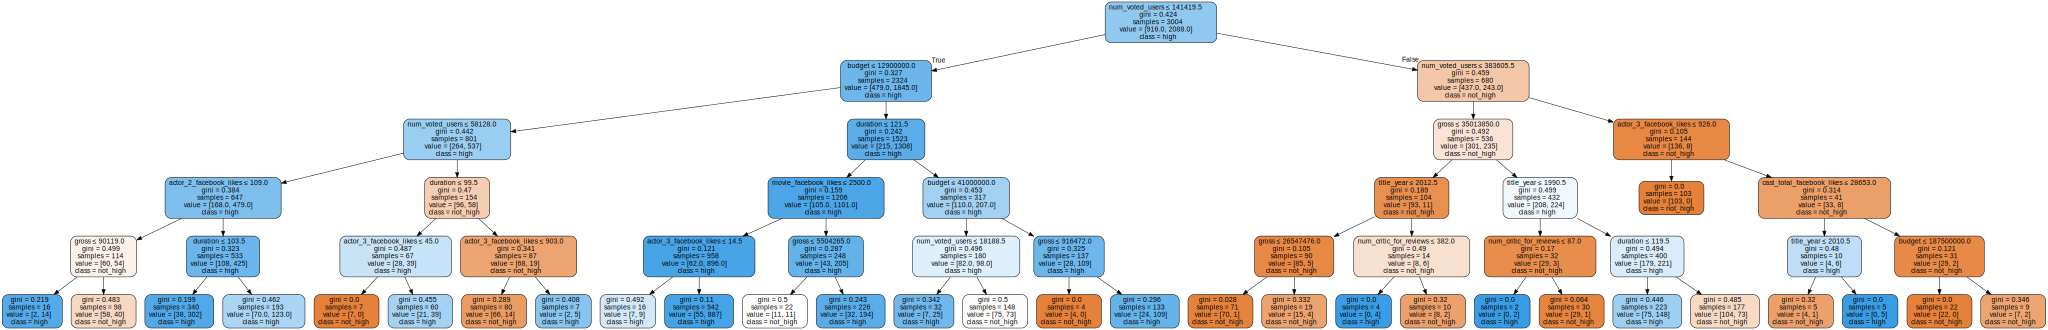

In [44]:
#13. Visualize the decision tree
#

# YOUR CODE HERE
#based on decison tree ipynb file example
decisiontree_visual = export_graphviz(
    model.best_estimator_.named_steps['classifier'],
    feature_names=x_train.columns,
    class_names=['not_high', 'high'],
    filled=True,
    rounded=True,
    special_characters=True
)   
graph = graphviz.Source(decisiontree_visual)
graph  # this displays it in the notebook

## 14. View the results, comment on how the model performed using the metrics you selected. 

In [45]:
#14. Review the cross-validation results from GridSearchCV
#
# Hint: model.cv_results_ contains all scores for every parameter combination.
# Extract mean and std for each scoring metric and organize into a DataFrame.


# YOUR CODE HERE
# cv_results_ is a dictionary — print to see all available keys
print(model.cv_results_)
print(model.cv_results_.keys())


{'mean_fit_time': array([0.00859072, 0.01071811, 0.01300151, 0.0195674 , 0.02227147,
       0.02641924, 0.02386299, 0.0261833 , 0.0319904 , 0.03015103,
       0.03132092]), 'std_fit_time': array([0.00234108, 0.00425677, 0.00284916, 0.00769995, 0.00671398,
       0.00720022, 0.00351787, 0.00451461, 0.01043729, 0.00464088,
       0.00471458]), 'mean_score_time': array([0.01421011, 0.01311176, 0.01141823, 0.01483722, 0.01453425,
       0.01427895, 0.01161986, 0.01110762, 0.01171225, 0.01258629,
       0.01189651]), 'std_score_time': array([0.00564855, 0.00510113, 0.00133615, 0.01035122, 0.00658243,
       0.00501209, 0.00328898, 0.0039445 , 0.00343254, 0.00302992,
       0.00318183]), 'param_classifier__max_depth': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False],
       fill_value=999999), 'params': [{'classifier__max_depth': 1}, {'classifier__max_depth': 2}, {'classif

In [46]:
# extract mean and std for each scoring metric
auc     = model.cv_results_['mean_test_roc_auc']
recall  = model.cv_results_['mean_test_recall']
bal_acc = model.cv_results_['mean_test_balanced_accuracy']

SDauc     = model.cv_results_['std_test_roc_auc']
SDrecall  = model.cv_results_['std_test_recall']
SDbal_acc = model.cv_results_['std_test_balanced_accuracy']

In [47]:
# note: key is 'param_classifier__max_depth' because we are using a pipeline
depth = np.unique(model.cv_results_['param_classifier__max_depth']).data


In [48]:
# build DataFrame
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc, SDauc, SDrecall, SDbal_acc)),
               columns=['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

print(final_model.to_string(index=False))

 depth      auc   recall  bal_acc    aucSD  recallSD  bal_accSD
     1 0.669773 0.890225 0.669773 0.020385  0.028386   0.020385
     2 0.723299 0.894627 0.665744 0.015925  0.033165   0.023716
     3 0.779165 0.922612 0.654221 0.016857  0.039820   0.032057
     4 0.796740 0.897427 0.695668 0.016637  0.041088   0.028698
     5 0.804861 0.887261 0.715705 0.017878  0.031123   0.022646
     6 0.798921 0.891559 0.717631 0.018424  0.028516   0.020008
     7 0.785663 0.883036 0.721324 0.019281  0.025755   0.015453
     8 0.756521 0.874229 0.721291 0.021714  0.021655   0.014552
     9 0.727790 0.866279 0.717417 0.023617  0.024634   0.017448
    10 0.712247 0.854499 0.721255 0.025148  0.025660   0.019019
    11 0.698937 0.843579 0.720699 0.021641  0.023964   0.018419


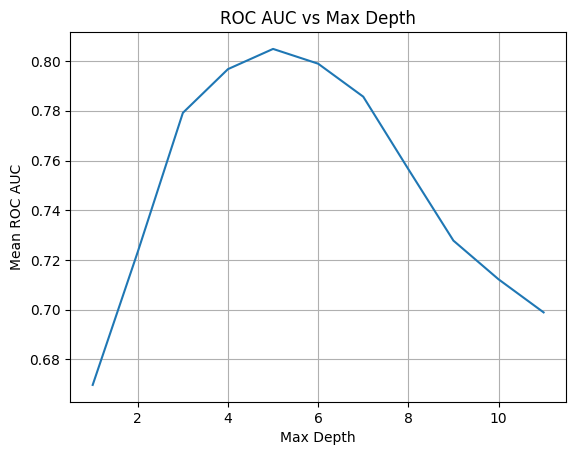

In [49]:
# plot AUC vs depth to visually confirm best depth
print(plt.plot(final_model.depth, final_model.auc))
plt.xlabel('Max Depth')
plt.ylabel('Mean ROC AUC')
plt.title('ROC AUC vs Max Depth')
plt.grid()  

The model showed an increase in AUC from depth 1 (0.67) to depth 5 (0.80) where it peaked, then gradually declined at deeper levels. Showing that depth 5 is the best spot to capture real patterns without memorizing noise. Also, Recall remained consistently high across all depths (above 0.88) showing that the model is good at catching high rated movies throughout

## 15. Which variables appear to be contributing the most (variable importance), what patterns do you notice?

In [50]:
#15. Compute and display variable importance
#
# Hint: The DecisionTreeClassifier lives inside the pipeline.
# Access it with best.named_steps['classifier'] to get feature_importances_.
#


# YOUR CODE HERE
best_tree = model.best_estimator_.named_steps['classifier']
feature_importances = best_tree.feature_importances_
importance_df = pd.DataFrame({
    'feature': x.columns,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)
print(importance_df)

                      feature  importance
6             num_voted_users    0.534186
1                    duration    0.141692
10                     budget    0.094041
5                       gross    0.090810
12     actor_2_facebook_likes    0.038783
11                 title_year    0.037528
3      actor_3_facebook_likes    0.031131
0      num_critic_for_reviews    0.014113
14       movie_facebook_likes    0.009169
7   cast_total_facebook_likes    0.008545
2     director_facebook_likes    0.000000
4      actor_1_facebook_likes    0.000000
8        facenumber_in_poster    0.000000
9        num_user_for_reviews    0.000000
13               aspect_ratio    0.000000


- num_voted_users is the most important feature at 0.534 with duration at (0.14) and budget at (0.09) suggesting that longer and more expensive movies tend to score higher
- social media aspects such as actor_1_facebook_likes and director_facebook_likes at 0 show that a following has no predictive power over IMDB score

## 16. Use the predict method on the tune data and print out the results.

In [51]:
#16. Generate predictions on the tune (validation) set
#
# Hint: The Pipeline's .predict() runs all preprocessing steps end-to-end.
# Use .predict_proba() to get probability estimates for metrics like AUC.


# YOUR CODE HERE
y_pred = model.predict(x_tune)  
y_proba = model.predict_proba(x_tune)[:, 1]  # probability of the positive class

## 17. How does the model perform on the tune data? Does the model need to adjusted why or why not?

In [52]:
#17. Evaluate model performance on the tune set
#
# Hint: Compute AUC, recall, balanced accuracy, and overall accuracy.
# Compare these to the cross-validation scores to check for overfitting.


# YOUR CODE HERE
auc = metrics.roc_auc_score(y_tune, y_proba)
recall = metrics.recall_score(y_tune, y_pred)
balanced_acc = metrics.balanced_accuracy_score(y_tune, y_pred)
accuracy = metrics.accuracy_score(y_tune, y_pred)
print("AUC", auc)
print("Recall", recall)
print("Balanced Accuracy", balanced_acc)
print("Accuracy", accuracy) 

AUC 0.8041439806412582
Recall 0.8659003831417624
Balanced Accuracy 0.7355817705182497
Accuracy 0.7866666666666666


The model results: tune AUC: 0.804, recall: 0.866, balanced accuracy: 0.736, accuracy: 0.787 are very close to the CV scores (AUC 0.804 in CV vs 0.804 on tune) meaning the model is not overfitting
The recall of 0.866 means we catch 87% of actually high rated movies which is 
good however, he model could be adjusted to improve balanced accuracy (0.736) which is a bit low

## 18. Print out the confusion matrix for the tune data, what does it tell you about the model?

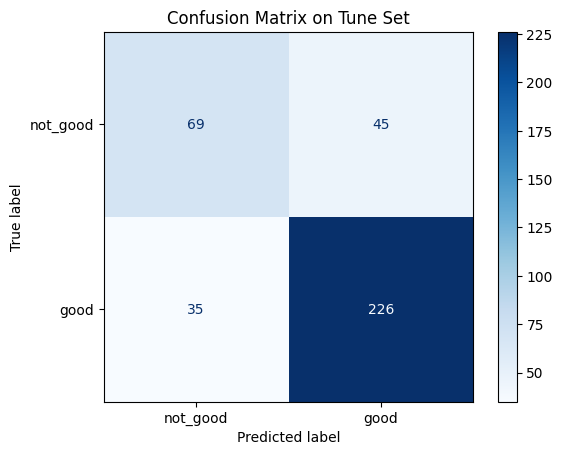

In [53]:
#18. Display confusion matrix on the tune set
#
# Hint: The Pipeline object works directly with ConfusionMatrixDisplay.


# YOUR CODE HERE
cm = metrics.confusion_matrix(y_tune, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['not_good', 'good'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Tune Set")
plt.show()  

The confusion matrix shows that the model is very good at identifying few false negatives which are highly rated 
movies; however, produces more false positives (predicting a movie will be rated high when it actually is not). For the studio, are more acceptable than false negatives because missing a great movie costs more than occasionally greenlighting a movie that ends up underperforming.

## 19. What are the top 3 movies based on the tune set? Which variables are most important in predicting the top 3 movies?

In [54]:
#19. Identify the top 3 movies from the tune set predictions
#
# Hint: Use predict_proba to get the probability of the positive class,
# then sort to find the top predictions. Cross-reference with variable importance.


# YOUR CODE HERE
positive_class = model.predict(x_tune)
positive_proba = model.predict_proba(x_tune)[:, 1]
tune_results = x_tune.copy()
tune_results['actual'] = y_tune
tune_results['predicted'] = positive_class
tune_results['predicted_proba'] = positive_proba
top_predictions = tune_results.sort_values(by='predicted_proba', ascending=False).head(3)
print(top_predictions)  

tune_results['movie_title'] = movie_metadata.loc[x_tune.index, 'movie_title'].values
print(tune_results.sort_values('predicted_proba', ascending=False)[['movie_title', 'predicted_proba', 'actual']].head(3))

     num_critic_for_reviews  duration  director_facebook_likes  \
599                   286.0     115.0                    101.0   
47                    590.0     132.0                  14000.0   
510                   384.0     125.0                    255.0   

     actor_3_facebook_likes  actor_1_facebook_likes        gross  \
599                   585.0                 13000.0   25121291.0   
47                    928.0                 19000.0  228756232.0   
510                   963.0                 11000.0  117698894.0   

     num_voted_users  cast_total_facebook_likes  facenumber_in_poster  \
599           177653                      15708                   1.0   
47            395573                      21411                   0.0   
510           447979                      13312                   6.0   

     num_user_for_reviews       budget  title_year  actor_2_facebook_likes  \
599                 279.0   50000000.0      2013.0                  1000.0   
47           

The top 3 movies are - Escape Plan, Star Trek Into Darkness, and Now You See Me. With the most important variables driving these predictions being num_voted_users, budget, and gross

## 20. Use a different hyperparameter for the grid search function and go through the process again using the tune set, make sure to create a new model object. Why did you choose the changes you did?

In [55]:
#20. Re-run the pipeline with a different hyperparameter grid
#
# Hint: Try adding other hyperparameters to the grid. Remember to prefix
# each parameter name with 'classifier__' because of the Pipeline.


# YOUR CODE HERE
grid = {
    'classifier__max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    'classifier__min_samples_split': [2, 5, 10], # added to prevent overfitting by requiring a minimum number of samples to split an internal node
    'classifier__ccp_alpha': [.001, .01, .1], # added to prevent overfitting by pruning the tree based on cost complexity
}
search_2 = GridSearchCV(
    pipe, grid, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc'
)
model_2 = search_2.fit(x_train, y_train)
print(model_2.best_params_)

{'classifier__ccp_alpha': 0.001, 'classifier__max_depth': 6, 'classifier__min_samples_split': 10}


We added the parameter min_samples_split to prevent the tree from splitting nodes that have 
too few samples to help reduce overfitting by keeping. Also added ccp_alpha to prevent overfitting by getting rid of branches that don't really improve the model helping to cointrol complexity / overfitting

## 21. Did the model improve with the new hyperparameter search?

In [56]:
#21. Compare the two models on the tune set
#
# Hint: Evaluate the new model's performance on X_tune / y_tune and
# compare the metrics (AUC, recall, balanced accuracy) with the first model.

# YOUR CODE HERE
new_y_pred = model_2.predict(x_tune)   # we use model_2 not model
new_y_proba = model_2.predict_proba(x_tune)[:, 1]
new_auc = metrics.roc_auc_score(y_tune, new_y_proba)
new_recall = metrics.recall_score(y_tune, new_y_pred)
new_balanced_acc = metrics.balanced_accuracy_score(y_tune, new_y_pred)
new_accuracy = metrics.accuracy_score(y_tune, new_y_pred)
print("New AUC", new_auc)
print("New Recall", new_recall)
print("New Balanced Accuracy", new_balanced_acc)
print("New Accuracy", new_accuracy)     

New AUC 0.8251495597230624
New Recall 0.8888888888888888
New Balanced Accuracy 0.7339181286549707
New Accuracy 0.7946666666666666


Yes. Model 2 improved across all metrics with AUC increasing from 0.804 -> 0.825, Recall from 0.866 -> 0.889 
and Accuracy from 0.787 -> 0.795. 

## 22. Using the better model, predict the test data and print out the results.

In [57]:
#22. Final evaluation on the test set using the better model
#
# Hint: This should only be done ONCE after all tuning is complete.
# The Pipeline handles the full predict flow automatically.


# YOUR CODE HERE
final_y_pred = model_2.predict(x_test)
final_y_proba = model_2.predict_proba(x_test)[:, 1]
final_auc = metrics.roc_auc_score(y_test, final_y_proba)
final_recall = metrics.recall_score(y_test, final_y_pred)
final_balanced_acc = metrics.balanced_accuracy_score(y_test, final_y_pred)
final_accuracy = metrics.accuracy_score(y_test, final_y_pred)
print("Final AUC", final_auc)
print("Final Recall", final_recall)
print("Final Balanced Accuracy", final_balanced_acc)
print("Final Accuracy", final_accuracy)     

Final AUC 0.8436948192570382
Final Recall 0.9080459770114943
Final Balanced Accuracy 0.7540229885057471
Final Accuracy 0.8138297872340425


## 23. Summarize what you learned along the way and make recommendations to your boss on how this could be used moving forward, being careful not to over promise.

In [58]:
#23. Write your summary here as comments or in a markdown cell above
#
# Consider:
# - How well did the model perform overall?
# - Which features were most important for predicting high IMDB scores?
# - How did the model's performance compare across train / tune / test?
# - What are the limitations of this approach?
# - What would you recommend as next steps?

# YOUR SUMMARY HERE

The model performed well with a tune AUC of 0.80 and improved to 0.84 by the final test set; with a Recall of 0.91 on the test set, meaning the model correctly identified 91% of actually high rated movies. The model also ahd an Accuracy of 0.81 thereby beating the baserate of 0.30, which tells us that the model is actually learning real patterns and not just guessing.
The most important feature to predict IMDB scores were num_voted_users, duration and budget.
Our model showed an improved performance from Model 1's AUC of 0.80 to Model 2's AUC of 0.84 after adding parametres min_samples_split and ccp_alpha to control tree complexity and reduce overfitting.
We did have some limitations which was taht only numeric features were used as categorical features like genre and director were excluded however that may have been a driving factor fornaudeince interets and therefore IMDB score improvement. Based on the model's performance, I would recommend that this model would be great at flagging potentially high rated movies as a screening tool however should not be the sole decision maker becayse a decision tree is just one tree making decisions alone. So we recommend monitoring 
performance on new releases and even considering the use of Random Forest as a next step because unlike decision trees it builds hundreds of trees with its results beiung based on a amjority vote. It is also less likely to overfit and often performes better.